In [1]:
import ee

# run `earthengine authenticate` in terminal first

ee.Authenticate()
ee.Initialize(project="quick-composite-408320")

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_7TDKVSyKvBdmMqW?ref=4i2o6


In [2]:
# Load Sentinel-5P CH4 collection with date filter
collection = ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CH4') \
    .select('CH4_column_volume_mixing_ratio_dry_air') \
    .filterDate('2019-06-01', '2019-07-16')


In [5]:
import ee

# --- FIX: Define band name and Italy geometry before using them ---
band_name = 'CH4_column_volume_mixing_ratio_dry_air'
try:
    italy_geom  # if already defined in a previous session, skip redefining
except NameError:
    italy_fc = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Italy'))
    italy_geom = italy_fc.geometry()

# Functions ---------------------------------------------------------------
def has_data_over_region(img, region):
    """Check if image has valid data over the region by counting non-null pixels."""
    pixel_count = img.select(band_name).reduceRegion(
        reducer=ee.Reducer.count(),
        geometry=region,
        scale=10000,
        bestEffort=True,
        maxPixels=1e9
    ).get(band_name)
    return pixel_count

# Filter collection to only images with data over Italy
def filter_valid_images(ic, region, band):
    def add_pixel_count(img):
        count = img.select(band).reduceRegion(
            reducer=ee.Reducer.count(),
            geometry=region,
            scale=10000,
            bestEffort=True,
            maxPixels=1e9
        ).get(band)
        return img.set('pixel_count', count)
    ic_with_counts = ic.map(add_pixel_count)
    return ic_with_counts.filter(ee.Filter.gt('pixel_count', 0))

# -----------------------------------------------------------------------
print("Filtering to images with data over Italy...")
valid_collection = filter_valid_images(collection, italy_geom, band_name)
valid_size = valid_collection.size().getInfo()
print(f"Images with data over Italy: {valid_size} out of {collection.size().getInfo()}")

if valid_size > 0:
    def add_italy_mean(img):
        mean_val = img.select(band_name).reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=italy_geom,
            scale=10000,
            bestEffort=True,
            maxPixels=1e9
        ).get(band_name)
        return img.set({
            'date_str': img.date().format('YYYY-MM-dd'),
            'italy_mean': mean_val
        })

    processed = valid_collection.map(add_italy_mean)

    dates = processed.aggregate_array('date_str').getInfo()
    means = processed.aggregate_array('italy_mean').getInfo()

    results = []
    for date, mean in zip(dates, means):
        if mean is not None:
            results.append({'date': date, 'mean_ch4': mean})

    print(f"Found {len(results)} valid daily observations:")
    for i, result in enumerate(results[:10]):
        print(f"{i+1}: {result['date']} = {result['mean_ch4']:.2f}")
    if len(results) > 10:
        print(f"... and {len(results) - 10} more")
else:
    print("No images found with data over Italy in this period.")
    print("This could be due to cloud cover, sensor gaps, or QA filtering needs.")

Filtering to images with data over Italy...
Images with data over Italy: 48 out of 635
Images with data over Italy: 48 out of 635
Found 48 valid daily observations:
1: 2019-06-01 = 1867.84
2: 2019-06-02 = 1857.97
3: 2019-06-03 = 1842.03
4: 2019-06-04 = 1835.06
5: 2019-06-04 = 1812.60
6: 2019-06-05 = 1840.58
7: 2019-06-05 = 1845.77
8: 2019-06-06 = 1852.28
9: 2019-06-07 = 1855.87
10: 2019-06-08 = 1858.71
... and 38 more
Found 48 valid daily observations:
1: 2019-06-01 = 1867.84
2: 2019-06-02 = 1857.97
3: 2019-06-03 = 1842.03
4: 2019-06-04 = 1835.06
5: 2019-06-04 = 1812.60
6: 2019-06-05 = 1840.58
7: 2019-06-05 = 1845.77
8: 2019-06-06 = 1852.28
9: 2019-06-07 = 1855.87
10: 2019-06-08 = 1858.71
... and 38 more


In [6]:
# Build DataFrame of valid daily means & summary stats
import pandas as pd

try:
    results  # ensure results exists from previous cell
except NameError:
    raise RuntimeError("Run the previous cell that builds 'results' first.")

# Some days may repeat (multiple orbits); aggregate by date average
import math
from statistics import mean

# Collect by date
by_date = {}
for r in results:
    d = r['date']
    v = r['mean_ch4']
    if v is None or (isinstance(v, float) and (math.isnan(v) or math.isinf(v))):
        continue
    by_date.setdefault(d, []).append(v)

rows = [(d, mean(vals)) for d, vals in by_date.items()]
if not rows:
    raise ValueError("No numeric rows to build DataFrame.")

import datetime as dt

df = pd.DataFrame(rows, columns=['date', 'mean_ch4'])
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("DataFrame shape:", df.shape)
print("First 5 rows:\n", df.head())
print("\nSummary statistics:\n", df['mean_ch4'].describe())

DataFrame shape: (42, 2)
First 5 rows:
         date     mean_ch4
0 2019-06-01  1867.843582
1 2019-06-02  1857.969457
2 2019-06-03  1842.034047
3 2019-06-04  1823.831191
4 2019-06-05  1843.177362

Summary statistics:
 count      42.000000
mean     1852.124897
std         8.934719
min      1823.831191
25%      1846.959699
50%      1854.268892
75%      1858.162893
max      1867.843582
Name: mean_ch4, dtype: float64


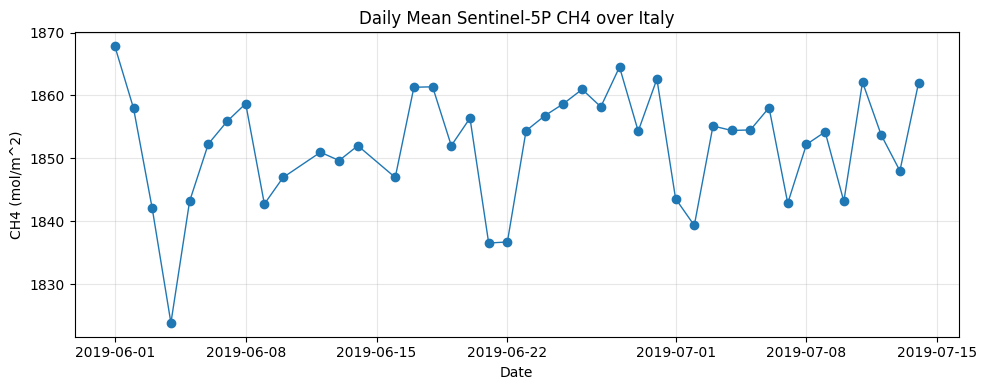

In [7]:
# Time series plot of daily mean CH4
try:
    df
except NameError:
    raise RuntimeError("Run the DataFrame cell first.")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df['date'], df['mean_ch4'], marker='o', linewidth=1)
plt.title('Daily Mean Sentinel-5P CH4 over Italy')
plt.xlabel('Date')
plt.ylabel('CH4 (mol/m^2)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

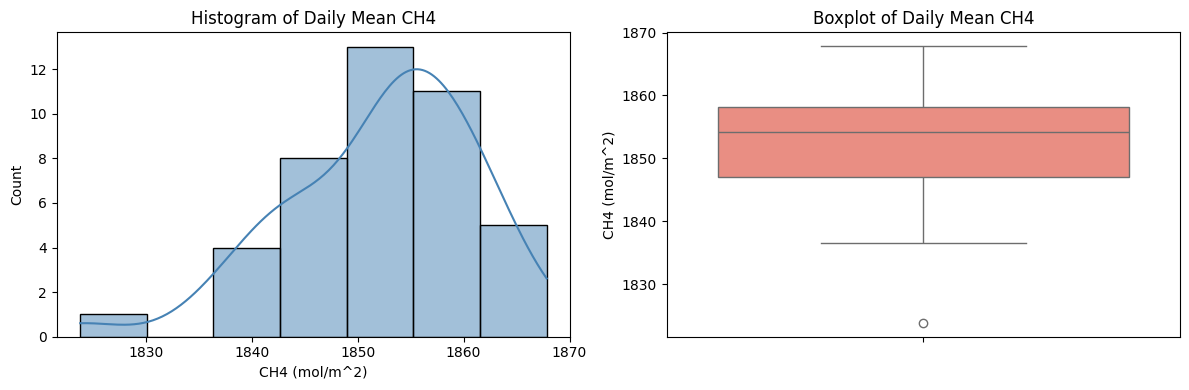

Skewness: -0.8824905833261837
Kurtosis: 1.0851838022845706


In [8]:
# Distribution plots (histogram & boxplot)
try:
    df
except NameError:
    raise RuntimeError("Run the DataFrame cell first.")

import matplotlib.pyplot as plt
import seaborn as sns

# Install seaborn if missing
try:
    sns.set_theme
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn'])
    import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['mean_ch4'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Histogram of Daily Mean CH4')
axes[0].set_xlabel('CH4 (mol/m^2)')

sns.boxplot(y=df['mean_ch4'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Daily Mean CH4')
axes[1].set_ylabel('CH4 (mol/m^2)')

plt.tight_layout()
plt.show()

print('Skewness:', df['mean_ch4'].skew())
print('Kurtosis:', df['mean_ch4'].kurt())

Anomalies detected:
               mean_ch4    zscore
date                             
2019-06-04  1823.831191 -3.219984


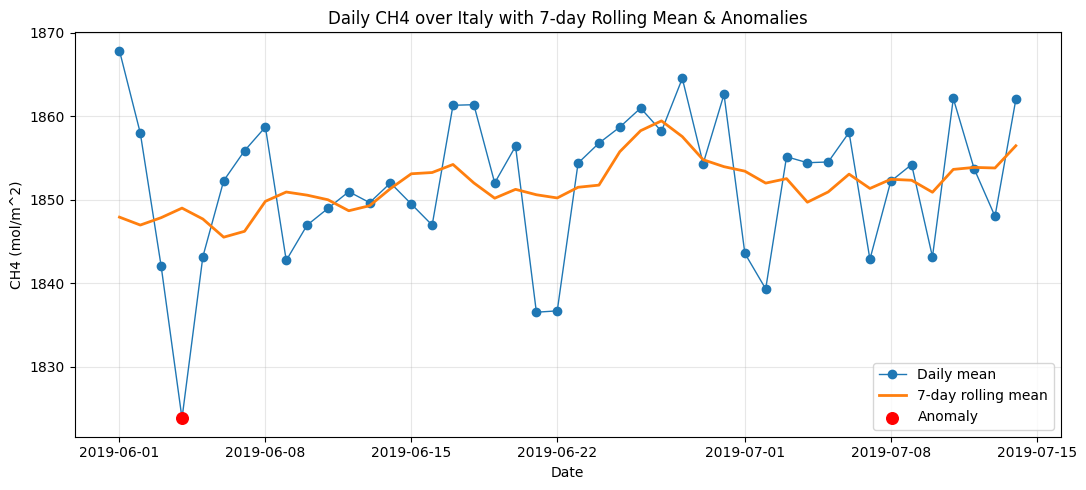

Total anomalies: 1 (|z|>2). Consider verifying data quality or regional events.


In [9]:
# Rolling 7-day mean and anomaly detection
try:
    df
except NameError:
    raise RuntimeError("Run the DataFrame cell first.")

import matplotlib.pyplot as plt

# Ensure daily frequency (reindex if gaps)
df_daily = df.set_index('date').asfreq('D')
# Forward/back fill small gaps (optional, limit=1 day)
df_daily['mean_ch4'] = df_daily['mean_ch4'].interpolate(limit=1)

# Rolling window (centered)
df_daily['roll7'] = df_daily['mean_ch4'].rolling(window=7, center=True, min_periods=3).mean()

# Z-score relative to full period
global_mean = df_daily['mean_ch4'].mean()
global_std = df_daily['mean_ch4'].std()
df_daily['zscore'] = (df_daily['mean_ch4'] - global_mean) / global_std

# Flag anomalies (|z| > 2)
df_daily['anomaly'] = df_daily['zscore'].abs() > 2

print("Anomalies detected:")
print(df_daily[df_daily['anomaly']][['mean_ch4','zscore']])

plt.figure(figsize=(11,5))
plt.plot(df_daily.index, df_daily['mean_ch4'], label='Daily mean', marker='o', linewidth=1)
plt.plot(df_daily.index, df_daily['roll7'], label='7-day rolling mean', linewidth=2)

# Plot anomalies
anoms = df_daily[df_daily['anomaly']]
plt.scatter(anoms.index, anoms['mean_ch4'], color='red', s=70, zorder=5, label='Anomaly')

plt.title('Daily CH4 over Italy with 7-day Rolling Mean & Anomalies')
plt.xlabel('Date')
plt.ylabel('CH4 (mol/m^2)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Basic interpretation hint
if not anoms.empty:
    print(f"Total anomalies: {len(anoms)} (|z|>2). Consider verifying data quality or regional events.")
else:
    print("No anomalies beyond |z|>2 threshold.")

In [11]:
# Interactive map overlay of CH4 over Italy (robust version)
# Handles empty date ranges and re-loads base collection if needed.

import ee

# Ensure essentials
band_name = 'CH4_column_volume_mixing_ratio_dry_air'
try:
    italy_geom
except NameError:
    italy_fc = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Italy'))
    italy_geom = italy_fc.geometry()

# User-adjustable parameters -------------------------------------------------
start_date = '2019-01-01'
end_date   = '2019-02-01'   # adjust window for different composites
composite_method = 'mean'    # 'mean' | 'median' | 'first'
# ----------------------------------------------------------------------------

# Re-load an unfiltered base collection (so dates outside earlier filter still work)
base_collection = ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_CH4').select(band_name)
filtered = base_collection.filterDate(start_date, end_date)

col_size = filtered.size().getInfo()
print(f"Filtered collection size for {start_date} -> {end_date}: {col_size}")

if col_size == 0:
    print("No images found in requested date range. Try adjusting dates (e.g., 2019-06-01 to 2019-07-16) or verifying product availability.")
else:
    if composite_method == 'mean':
        image = filtered.mean()
    elif composite_method == 'median':
        image = filtered.median()
    elif composite_method == 'first':
        image = ee.Image(filtered.first())
    else:
        raise ValueError("Unsupported composite_method; choose 'mean','median','first'.")

    # Verify image has the band before continuing
    band_names = image.bandNames().getInfo()
    if band_name not in band_names:
        print("Composite produced no bands. Aborting visualization.")
    else:
        image = image.select(band_name).clip(italy_geom)

        # Quantile stretch with fallback
        try:
            q = image.reduceRegion(
                reducer=ee.Reducer.percentile([5,95]),
                geometry=italy_geom,
                scale=10000,
                bestEffort=True,
                maxPixels=1e9
            ).getInfo()
            p5  = q.get(f'{band_name}_p5') if q else None
            p95 = q.get(f'{band_name}_p95') if q else None
        except Exception as e:
            print('Quantile reduction failed, using defaults (1800-1900).', e)
            p5, p95 = None, None

        vmin = 1800 if (p5 is None) else p5
        vmax = 1900 if (p95 is None) else p95
        if vmin == vmax:
            vmax = vmin + 1  # avoid zero range

        vis_params = {
            'min': vmin,
            'max': vmax,
            'palette': ['0d0887','5c01a6','9c179e','cc4778','ed7953','fb9f3a','fdca26','f0f921']
        }
        print('Visualization stretch:', vis_params['min'], 'to', vis_params['max'])

        # Try geemap; fallback to folium
        _use_geemap = True
        try:
            import geemap.foliumap as geemap
        except Exception:
            _use_geemap = False

        if _use_geemap:
            m = geemap.Map(center=[41.9, 12.5], zoom=5)
            m.addLayer(image, vis_params, f'CH4 {composite_method} {start_date} to {end_date}')
            m.addLayerControl()
            try:
                m.add_colorbar(vis_params=vis_params, label='CH4 (mol/m^2)')
            except Exception:
                pass
            display(m)
        else:
            import folium
            m = folium.Map(location=[41.9, 12.5], zoom_start=5, tiles='cartodbpositron')
            def add_ee_layer(folium_map, ee_image, vis, name):
                map_info = ee_image.getMapId(vis)
                tile_url = map_info['tile_fetcher'].url_format
                folium.raster_layers.TileLayer(
                    tiles=tile_url,
                    attr='Google Earth Engine',
                    name=name,
                    overlay=True,
                    control=True
                ).add_to(folium_map)
                return tile_url
            tile_url = add_ee_layer(m, image, vis_params, f'CH4 {composite_method}')
            folium.LayerControl().add_to(m)
            display(m)
            print('Tile URL template (use in Leaflet frontend):')
            print(tile_url)

        # Tile template for external integration
        try:
            map_info = image.getMapId(vis_params)
            tile_template = map_info['tile_fetcher'].url_format
            print('\nReusable tile URL template:')
            print(tile_template)
        except Exception as e:
            print('Could not generate tile URL template:', e)

        # Static thumbnail
        try:
            thumb_params = {
                'region': italy_geom,
                'min': vis_params['min'],
                'max': vis_params['max'],
                'dimensions': 512,
                'palette': vis_params['palette']
            }
            thumb_url = image.getThumbURL(thumb_params)
            print('\nStatic thumbnail URL:', thumb_url)
        except Exception as e:
            print('Thumbnail generation failed:', e)

        # Export snippet (commented)
        # task = ee.batch.Export.image.toDrive(
        #     image=image,
        #     description=f'Italy_CH4_{composite_method}_{start_date}_{end_date}',
        #     folder='earthengine',
        #     fileNamePrefix=f'italy_ch4_{composite_method}_{start_date}_{end_date}',
        #     region=italy_geom,
        #     scale=10000,
        #     maxPixels=1e13
        # )
        # task.start()
        # print('Export started:', task.id)


Filtered collection size for 2019-01-01 -> 2019-02-01: 438
Visualization stretch: 1833.750188343919 to 1871.3286604755642
Visualization stretch: 1833.750188343919 to 1871.3286604755642


Tile URL template (use in Leaflet frontend):
https://earthengine.googleapis.com/v1/projects/quick-composite-408320/maps/a45151764546ea54166d0a4ba05333eb-c5346db08c0eecadae6e29328657cfdd/tiles/{z}/{x}/{y}

Reusable tile URL template:
https://earthengine.googleapis.com/v1/projects/quick-composite-408320/maps/a45151764546ea54166d0a4ba05333eb-dc25d991f9f973fdfc747f5bb0915028/tiles/{z}/{x}/{y}

Reusable tile URL template:
https://earthengine.googleapis.com/v1/projects/quick-composite-408320/maps/a45151764546ea54166d0a4ba05333eb-dc25d991f9f973fdfc747f5bb0915028/tiles/{z}/{x}/{y}

Static thumbnail URL: https://earthengine.googleapis.com/v1/projects/quick-composite-408320/thumbnails/859c203b641562fca3c70220712bd9da-f9825251c1f91a13579529a5cbfe84c9:getPixels

Static thumbnail URL: https://earthengine.googleapis.com/v1/projects/quick-composite-408320/thumbnails/859c203b641562fca3c70220712bd9da-f9825251c1f91a13579529a5cbfe84c9:getPixels


# Data Report: Sentinel-5P Methane (CH4) over Italy

Two conceptual layers of data:
1. Raw imagery: Individual overpass images (multiple per day) with per-pixel CH4 values.
2. Aggregated dataset (analysis level): Daily mean CH4 over Italy (after filtering images that contain valid pixels over the region). Multiple overpasses on the same date are averaged to a single daily metric.


You can recompute counts dynamically (example):
```python
raw_size = collection.size().getInfo()
valid_size = valid_collection.size().getInfo()
unique_days = df['date'].nunique()
raw_size, valid_size, unique_days
```

## Features / Dimensions
Final analytical table (`df`):
- `date` (datetime64[ns]): Calendar date of observation (aggregated across all overpasses on that day)
- `mean_ch4` (float): Mean methane column (mol/m^2) over Italy for that date

Intermediate / auxiliary fields generated later (not part of core raw aggregation):
- `roll7` (float): 7-day centered rolling mean (used for smoothing / trend visualization)
- `zscore` (float): Standardized anomaly indicator relative to full-period mean/std
- `anomaly` (bool): Flag where |zscore| > 2

Underlying imagery also contains additional QA and ancillary bands (not yet leveraged here). Incorporating quality flags (e.g., `qa_value`) would further refine data reliability.

## Data Types
| Field | Type | Notes |
|-------|------|-------|
| date | DateTime | Converted from string `YYYY-MM-DD` using pandas |
| mean_ch4 | Float64 | Derived aggregation (mean over region); NaN rows filtered out |
| roll7 | Float64 | Derived; may contain NaN at edges due to window centering |
| zscore | Float64 | Derived; depends on full-period stats |
| anomaly | Boolean | Threshold-based flag |

## Distribution Characteristics
- Distribution inspected via histogram + KDE and boxplot (see distribution cell)
- Summary statistics printed (count, mean, std, min, quartiles, max)
- Skewness and kurtosis reported; helps assess normality assumption for anomaly detection
- Rolling mean chart + anomalies highlight deviations beyond |z| > 2 (none or few expected in relatively short window)

## Temporal Characteristics
- Daily granularity; some dates missing due to cloud cover, retrieval gaps, orbital geometry, or QA filtering (images with zero valid pixels are excluded)
- Multiple overpasses per day averaged (simple arithmetic mean). Alternative aggregation (median or weighted by pixel count) could be considered.
- Short analysis window (≈ 6 weeks) limits robust seasonal inference.

## Spatial Characteristics
- Region: Entire Italy polygon (no sub-regional disaggregation yet)
- Aggregation: Region-wide mean; loses spatial heterogeneity (hotspots not represented in mean)
- Interactive composite map cell provides a spatial visualization using a quantile stretch (5th–95th percentile) and optional mean/median/first-image composite methods.

## Data Cleaning & Processing Steps
| Step | Action | Rationale |
|------|--------|-----------|
| Filter by date | `filterDate('2019-06-01','2019-07-16')` | Bound temporal scope |
| Band selection | `.select('CH4_column_volume_mixing_ratio_dry_air')` | Focus variable |
| Validity filter | Count non-null pixels over Italy; keep images with `pixel_count > 0` | Exclude empty / invalid images |
| Value filtering | Discard None / NaN / inf before aggregation | Ensure numeric integrity |
| Daily aggregation | Mean across multiple same-day images | Single representative daily metric |
| Interpolation (analysis only) | 1-day gap interpolation for rolling window | Smooth context for trend; not altering base stored daily means |
| Anomaly labeling | |zscore| > 2 threshold | Basic outlier indication |

No additional atmospheric correction or QA flag filtering performed yet (potential enhancement: apply official quality flags to refine reliability).

## Limitations & Assumptions
- No QA filtering (e.g., using `qa_value` thresholds) may allow noisier retrievals.
- Region-level averaging masks spatial variability; hotspots are not visible in numeric series.
- Short period limits detection of seasonal cycles.
- Simple z-score anomaly method assumes approximate stationarity; more advanced methods (STL decomposition, ARIMA residual analysis) could improve detection.
- Quantile-based visualization stretch depends on current date window; changing window alters color scaling.

## Potential Extensions
- Add QA filtering (e.g., `qa_value > 0.5`).
- Compute median & interquartile range per day for robustness to outliers.
- Subdivide Italy into administrative regions for spatial stratification.
- Integrate additional gases (NO2, CO) for multi-variable correlation analysis.
- Export cleaned daily table to CSV / Parquet for reproducibility.
- Implement interactive date slider map (e.g., ipyleaflet timelapse or geemap time series).


**In summary**, the dataset is a curated, temporally aggregated subset (daily means) of Sentinel-5P methane over Italy, with preliminary descriptive and exploratory analyses (distribution, rolling trends, anomaly flags, and spatial composite visualization). Further refinement should incorporate quality flags and spatial stratification for a more nuanced interpretation.
